In [ ]:
!pip install py3plex --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 12.4 MB/s eta 0:00:00


In [ ]:
from py3plex.core import multinet
from py3plex.dsl import Q, L

In [ ]:
network = multinet.multi_layer_network(network_type='multiplex', directed=False)
#Enlaces
network.add_edges([
    #Capa 'coauthor'
    ['Alice', 'coauthor', 'Bob', 'coauthor', 1],
    ['Bob', 'coauthor', 'Dave', 'coauthor', 1],
    ['Bob', 'coauthor', 'Eve', 'coauthor', 1],
    ['Eve', 'coauthor', 'Frank', 'coauthor', 1],
    ['Alice', 'coauthor', 'Grace', 'coauthor', 1],
    ['Grace', 'coauthor', 'Heidi', 'coauthor', 1],
    ['Frank', 'coauthor', 'Ivan', 'coauthor', 1],
    #Capa 'twitter'
    ['Alice', 'twitter', 'Carol', 'twitter', 1],
    ['Carol', 'twitter', 'Dave', 'twitter', 1],
    ['Eve', 'twitter', 'Ivan', 'twitter', 1],
    ['Ivan', 'twitter', 'Judy', 'twitter', 1],
    ['Alice', 'twitter', 'Judy', 'twitter', 1],
    ['Frank', 'twitter', 'Bob', 'twitter', 1],
    ['Heidi', 'twitter', 'Carol', 'twitter', 1]
], input_type="list")

network.summary()

{'Number of layers': 2,
 'Nodes': 17,
 'Edges': 14,
 'Mean degree': np.float64(1.6470588235294117),
 'CC': 3,
 'Mode': 'multiplex',
 'Replica model': 'partial',
 'Interlayer coupling': 'none',
 'Directed': False,
 'Weighted': True}

In [ ]:
#Añadir enlaces intercapa
personas = ['Alice', 'Bob', 'Dave', 'Eve', 'Frank', 'Heidi', 'Ivan', 'Judy']

#inter-layer edges
inter_layer_edges = []
for p in personas:
    #Conectamos al nodo consigo mismo entre 'coauthor' y 'twitter'
    #Formato: [nodo_origen, capa_origen, nodo_destino, capa_destino, peso]
    inter_layer_edges.append([p, 'coauthor', p, 'twitter', 1])
#Añadimos estos nuevos enlaces a la red
network.add_edges(inter_layer_edges, input_type="list")

network.summary()

{'Number of layers': 2,
 'Nodes': 18,
 'Edges': 22,
 'Mean degree': np.float64(2.4444444444444446),
 'CC': 1,
 'Mode': 'multiplex',
 'Replica model': 'partial',
 'Interlayer coupling': 'none',
 'Directed': False,
 'Weighted': True}

# Caminatas Aleatorias

- Para simular exploración y/o difusión
- Fundamental para PageRank
- Detectar comunidades
- *Embedding* de redes (Node2Vec, DeepWalk)

In [ ]:
from py3plex.dynamics import RandomWalkDynamics

#red, nodo inicial, probabilidad de quedarte en el mismo nodo
walk = RandomWalkDynamics(network, start_node=('Alice', 'coauthor'), lazy_probability=0.01)
walk.set_seed(42)
#Cuantos pasos dará la caminata aleatoria
results = walk.run(steps=20)

trajectory = results.get_measure("trajectory")
trajectory

[('Alice', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Alice', 'coauthor'),
 ('Bob', 'coauthor'),
 ('Alice', 'coauthor'),
 ('Alice', 'twitter'),
 ('Alice', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Alice', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Heidi', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Heidi', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Heidi', 'coauthor'),
 ('Grace', 'coauthor'),
 ('Heidi', 'coauthor'),
 ('Heidi', 'twitter'),
 ('Carol', 'twitter'),
 ('Dave', 'twitter'),
 ('Carol', 'twitter')]

# Modelos epidemiológicos

- SIR — Epidemias con inmunidad (Sarampeón). Todos se recuperan eventualmente.
- SIS — Enfermedades endémicas sin inmunidad (resfrío estacionario). Alcanza un equilibrio estacionario.

In [ ]:
from py3plex.dynamics import SIRDynamics
import networkx as nx

G = nx.karate_club_graph()

#SIR
sir = SIRDynamics(
    G,
    beta=0.3,              #Proba de infección
    gamma=0.1,             #Proba de recuperación
    initial_infected=0.1   #10% infectados inicialmente
)

sir.set_seed(42)

#Simular
results = sir.run(steps=100)

prevalence = results.get_measure("prevalence")
state_counts = results.get_measure("state_counts")
print(f"Peak prevalence: {prevalence.max():.2%}")
print(f"Final recovered: {state_counts['R'][-1]}")

Peak prevalence: 70.59%
Final recovered: 34


**Modelo SIR**

* $\beta \in (0, 1)$: **Probabilidad de transmisión por contacto**.
* $\gamma \in (0, 1)$: **Probabilidad de recuperación** por cada paso de tiempo.


In [ ]:
import matplotlib.pyplot as plt
from py3plex.dynamics import SIRDynamics
from IPython.display import Image, display

network = multinet.multi_layer_network(directed=False)

#Capa física
network.add_edges([
    ['Alice', 'física', 'Bob', 'física', 1],
    ['Bob', 'física', 'Carol', 'física', 1],
    ['Carol', 'física', 'Dave', 'física', 1]
], input_type="list")

#Capa digital
network.add_edges([
    ['Alice', 'digital', 'Dave', 'digital', 1],
    ['Alice', 'digital', 'Eve', 'digital', 1],
    ['Eve', 'digital', 'Frank', 'digital', 1]
], input_type="list")

#Enlaces Multiplex
personas_comunes = ['Alice', 'Dave']
for p in personas_comunes:
    network.add_edges([[p, 'física', p, 'digital', 1]], input_type="list")

#SIR
#beta: prob. infección, gamma: prob. recuperación
#Infectamos a Alice en la capa física para ver cómo se propaga a la digital
n_total = len(list(network.get_nodes()))
sir = SIRDynamics(network, beta=0.85, gamma=0.01, initial_infected=1/n_total)
results = sir.run(steps=50)

`state_counts` Nos dice cuantos nodos había en cada estado en cada tiempo *t*

In [ ]:
import pandas as pd

counts = results.get_measure("state_counts")
df_counts = pd.DataFrame(counts)
display(df_counts)

,S,I,R
0,7,1,0
1,6,2,0
2,4,4,0
3,2,6,0
4,1,7,0
5,1,7,0
6,0,8,0
7,0,8,0
8,0,7,1
9,0,6,2


La prevalencia $\rho(t)$ es la proporción de la población que se encuentra en el estado Infectado ($I$) en el tiempo $t$:
$$\rho(t) = \frac{I(t)}{N}$$

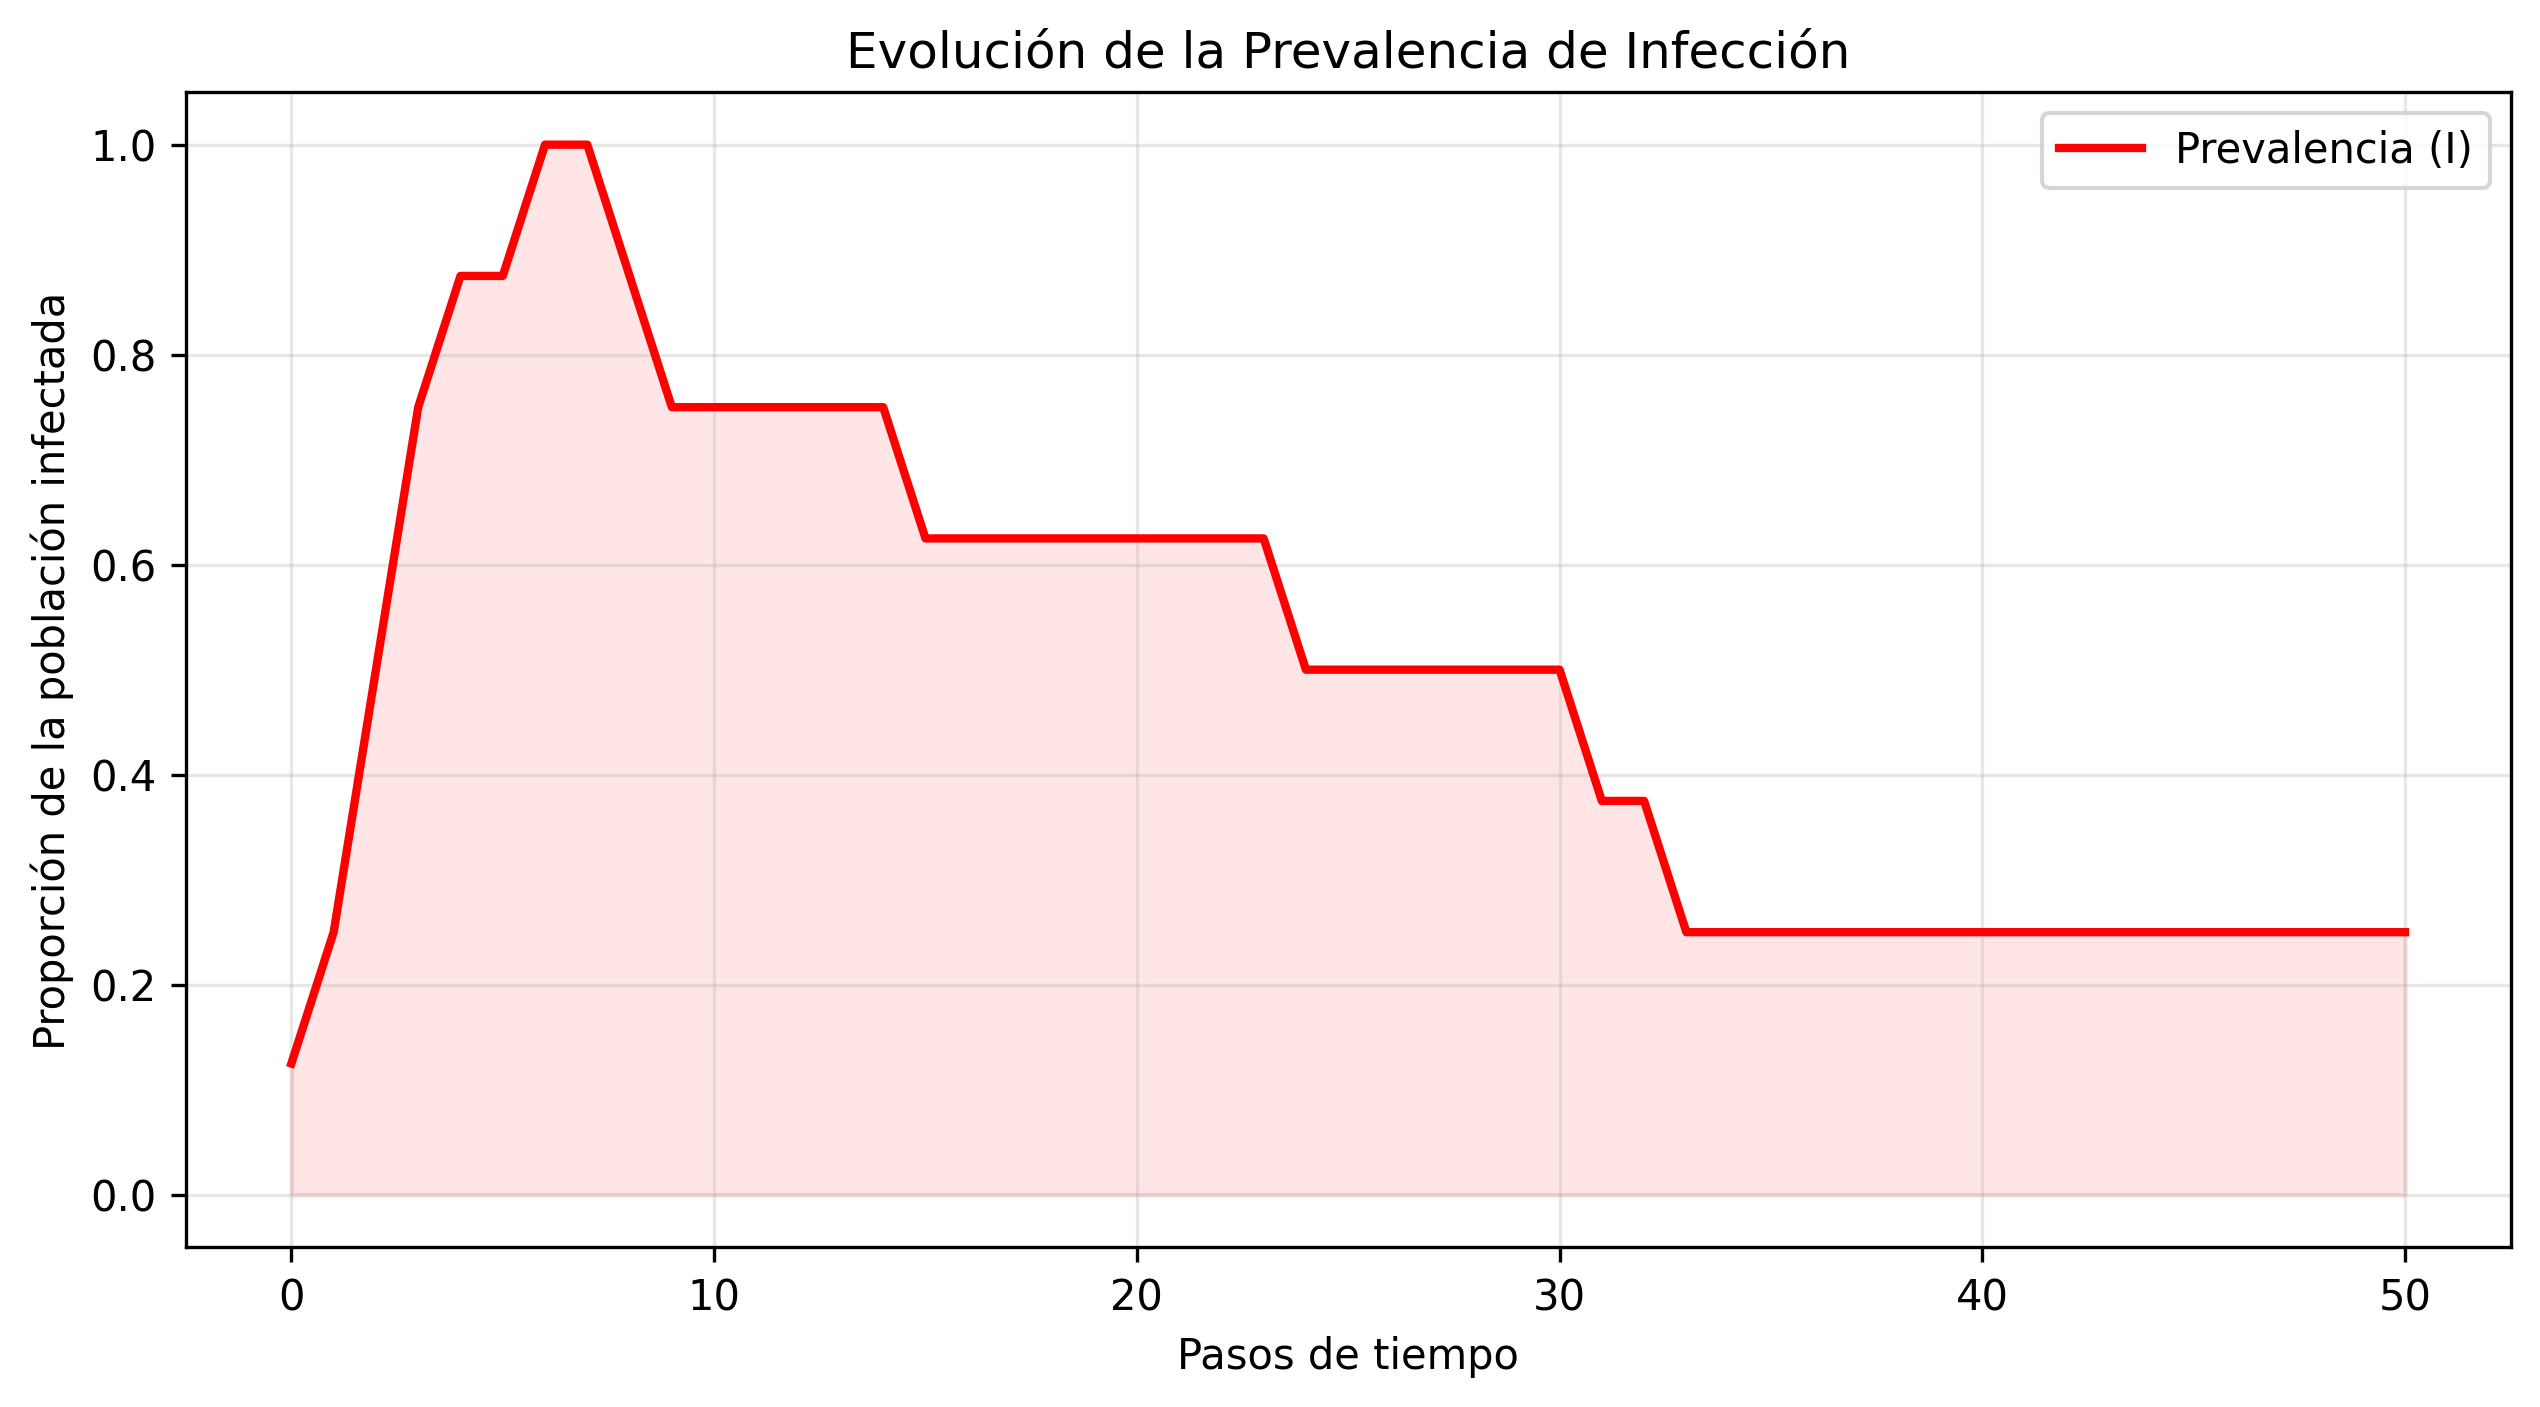

In [ ]:
#Extraemos la prevalencia
prevalence = results.get_measure("prevalence") #'prevalence', 'state_counts', 'trajectory'

plt.figure(figsize=(10, 5))
plt.plot(prevalence, color='red', linewidth=2, label='Prevalencia (I)')
plt.fill_between(range(len(prevalence)), prevalence, color='red', alpha=0.1)

plt.title("Evolución de la Prevalencia de Infección")
plt.xlabel("Pasos de tiempo")
plt.ylabel("Proporción de la población infectada")
plt.legend()
plt.grid(alpha=0.3)


plt.savefig("prevalencia_sir.png", dpi=300, bbox_inches='tight')
plt.close()

display(Image("prevalencia_sir.png"))

In [ ]:
# Extraer la historia completa de estados
trajectory = results.get_measure("trajectory")
trajectory[0]

{('Carol', 'física'): 'I',
 ('Alice', 'digital'): 'S',
 ('Frank', 'digital'): 'S',
 ('Dave', 'física'): 'S',
 ('Alice', 'física'): 'S',
 ('Eve', 'digital'): 'S',
 ('Bob', 'física'): 'S',
 ('Dave', 'digital'): 'S'}

In [ ]:
df_trayectoria = pd.DataFrame(trajectory)
df_trayectoria.columns = [f"{n} ({c})" for n, c in df_trayectoria.columns]
df_trayectoria.index.name = "Paso"

def color_estados(val):
    if val == 'S': color = '#3498db'
    elif val == 'I': color = '#e74c3c'
    elif val == 'R': color = '#2ecc71'
    return f'background-color: {color}; color: white; font-weight: bold'

styled_df = df_trayectoria.head(50).style.applymap(color_estados)
styled_df

/tmp/ipykernel_389/483437446.py:11: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_trayectoria.head(50).style.applymap(color_estados)


,Carol (física),Alice (digital),Frank (digital),Dave (física),Alice (física),Eve (digital),Bob (física),Dave (digital)
Paso,,,,,,,,
0,I,S,S,S,S,S,S,S
1,I,S,S,I,S,S,S,S
2,I,S,S,I,S,S,I,I
3,I,I,S,I,I,S,I,I
4,I,I,S,I,I,I,I,I
5,I,I,S,I,I,I,I,I
6,I,I,I,I,I,I,I,I
7,I,I,I,I,I,I,I,I
8,I,I,I,I,I,I,I,R


# Bootstraping

Creamos una red

In [ ]:
import numpy as np
import networkx as nx
from py3plex.core import multinet

network = multinet.multi_layer_network(directed=False)

#3 comunidades de 10 nodos cada una
n_nodos_por_comunidad = 10
comunidades = [range(0, 10), range(10, 20), range(20, 30)]

#CAPA FÍSICA (Estructura de "Islas")
for comm in comunidades:
    #Erdos-Renyi denso para cada comunidad
    subgrafo = nx.erdos_renyi_graph(len(comm), 0.4, seed=42)
    edges = []
    for u, v in subgrafo.edges():
        edges.append([comm[u], 'física', comm[v], 'física', 1])
    network.add_edges(edges, input_type="list")

#Conecta la comunidad 1 con la 2 a través de un solo enlace
network.add_edges([[9, 'física', 10, 'física', 1]], input_type="list")

#CAPA VIRTUAL (Estructura de "Estrella/Hub")
#El nodo 15 es un influencer que conecta a todos
hub_node = 15
digital_edges = []
for i in range(30):
    if i != hub_node:
        digital_edges.append([hub_node, 'virtual', i, 'virtual', 0.5])
network.add_edges(digital_edges, input_type="list")

#Conectamos a cada persona consigo misma entre capas
for i in range(30):
    network.add_edges([[i, 'física', i, 'virtual', 1]], input_type="list")

print(f"Red creada: {network.summary()}")

Red creada: {'Number of layers': 2, 'Nodes': 60, 'Edges': 120, 'Mean degree': np.float64(4.0), 'CC': 1, 'Mode': 'multilayer', 'Replica model': 'strict', 'Interlayer coupling': 'both', 'Directed': False, 'Weighted': True}


In [ ]:
import networkx as nx
from py3plex.uncertainty.bootstrap import bootstrap_metric

#Definimos qué queremos medir en cada réplica del bootstrap
def compute_betweenness(net):
    #Extraemos la red plana para que NetworkX pueda procesarla
    G = net.core_network #El cálculo SÍ toma en cuenta los enlaces de la capa virtual para encontrar los caminos más cortos.
    #Filtramos para que solo nos devuelva nodos de la capa 'física'
    nodes_fisica = [n for n in net.get_nodes() if n[1] == 'física']
    #alculamos la centralidad
    bc = nx.betweenness_centrality(G)
    #Devolvemos solo los de la capa física
    return {n: bc[n] for n in nodes_fisica if n in bc}


boot_results = bootstrap_metric(
    network, #Sobre que red queremos medir la centralidad
    compute_betweenness, #Función que queremos medir
    n_boot=1000, #Repetimos el proceso 1000 veces
    unit="edges", #Remuestreo de enlaces
    random_state=42 #Reproducibilidad
)
print("¡Bootstrap completado!")

¡Bootstrap completado!


In [ ]:
import pandas as pd

df_uncertainty = pd.DataFrame({
    'Nodo': boot_results['index'],
    'Promedio_BC': boot_results['mean'],
    'Error_Std': boot_results['std'],
    'IC_Bajo_95': boot_results['ci_low'],
    'IC_Alto_95': boot_results['ci_high']
})

#('nodo', 'capa') -> nodo
df_uncertainty['Nombre'] = df_uncertainty['Nodo'].apply(lambda x: x[0])

# Ordenamos por los que tienen más "incertidumbre" (Error estándar alto)
top_uncertain = df_uncertainty.sort_values(by='Error_Std', ascending=False).head(10)
print(top_uncertain[['Nombre', 'Promedio_BC', 'Error_Std', 'IC_Bajo_95', 'IC_Alto_95']])

    Nombre  Promedio_BC  Error_Std  IC_Bajo_95  IC_Alto_95
29       9     0.111312   0.071570    0.006095    0.285082
2       10     0.082728   0.064369    0.000000    0.230241
7       15     0.063986   0.064226    0.000000    0.212407
22      29     0.072364   0.061939    0.001347    0.235253
14      21     0.055387   0.058749    0.000000    0.222580
15      22     0.058074   0.055029    0.000000    0.205865
16      23     0.058584   0.052700    0.000000    0.194111
1        1     0.054748   0.050035    0.000000    0.192064
21      28     0.043757   0.049293    0.000000    0.167103
4       12     0.054954   0.049002    0.000000    0.183568


- Promedio BC: Media de la Centralidad de Intermediación en las 1000 simualciones.
- Error_Std: Desviación estándar del Bootstrap (que tanto varía la centralidad al hacer ligeros cambios)

En el análisis de redes, la métrica observada de un nodo (como su *Betweenness Centrality*) se denota como $\hat{\theta}$. Sin embargo, esta es una estimación puntual que no captura la variabilidad estructural. El **Bootstrap** simula el "universo" de redes posibles mediante el remuestreo de la red original $G$.

Sea $B = 1000$ el número de réplicas de bootstrap generadas. Para cada réplica $b$, se recalcula la métrica de interés (*betweeness en este caso*), obteniendo un conjunto de estimaciones:

$$\{\hat{\theta}^*_1, \hat{\theta}^*_2, \dots, \hat{\theta}^*_{1000}\}$$

Donde cada $\hat{\theta}^*_b$ representa el nodo en una versión ligeramente perturbada de la realidad.

---

Definición del Intervalo de Percentiles:

Para construir el **Intervalo de Confianza (IC)** al $95\%$, se utiliza la distribución de las réplicas **sin** asumir una distribución normal (enfoque no paramétrico). Primero, se ordenan las estimaciones de menor a mayor para obtener los estadísticos de orden:

$$\hat{\theta}^*_{(1)} \le \hat{\theta}^*_{(2)} \le \dots \le \hat{\theta}^*_{(1000)}$$

Para un nivel de significancia $\alpha = 0.05$, el intervalo se define por los límites que dejan el $2.5\%$ de las observaciones en cada cola:

* **IC_Bajo_95**: Corresponde al percentil $2.5$. Matemáticamente se extrae de la lista ordenada como:

$$\text{$IC_{Bajo}$} = \hat{\theta}^*_{(\lfloor B \cdot 0.025 \rfloor)}$$


* **IC_Alto_95**: Corresponde al percentil $97.5$. Se extrae de la lista ordenada como:

$$\text{$IC\_{Alto}$} = \hat{\theta}^*_{(\lfloor B \cdot 0.975 \rfloor)}$$



Este intervalo representa el rango de valores donde, con un $95\%$ de seguridad, se encuentra la verdadera importancia estructural del nodo ante variaciones en los enlaces de la red.

El nodo 9 tiene un `Promedio_BC` de 0.11, pero su `IC_Bajo_95` es casi cero (0.006) y su `IC_Alto_95` es 0.28.

El Bootstrap nos da este *insight*:
- El nodo 9 es un **puente** importante, pero es muy **frágil**.
- En algunas de las 1,000 redes, el enlace que lo conectaba se rompió y su influencia desapareció (`IC_Bajo` casi 0).